## **🥈 2. Breakout- & Peak-Alter je Disziplin**

**„Wann passieren die großen Leistungssprünge – und wann nicht mehr?“**

### **Warum #2?**

- Nutzt geburtsjahr, jahr, altersklasse
- Verbindet Statistik mit Sportrealität
- Ergebnisse sind oft **kontraintuitiv**

### **Kernfrage**

> Ist das Peak-Alter wirklich disziplinspezifisch – oder eher individuell?
> 

### **Überraschung**

- Früher Durchbruch ≠ frühes Leistungsmaximum
- Manche Disziplinen haben **lange Plateaus**

📊 Ideal für Heatmaps / Violinplots

🧠 Sehr gutes Beispiel für **Zeitreihen-Interpretation**

In [1]:
%run -i '../../DL Vorlesung/Preamble.py'
import numpy as np
import pandas as pd
import json
from pathlib import Path
import sys
# import seaborn as sns
# import matplotlib.pyplot as plt
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import plotting.plotting_style as plt
import util

In [2]:
plt.rcParams["text.usetex"]

True

In [3]:
data = util.load_data('../../data_csv/final_Data_iaaf_scores_neu.csv')
data

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146
...,...,...,...,...,...,...,...,...,...,...,...,...
226678,2023,M,14,Speerwurf,40.64,NaN,Tizian Zoeger,2010,LAC Aschersleben,29.04.2023,Schoenebeck,545
226679,2023,M,14,Speerwurf,40.48,NaN,Phil Matthias,2009,SV Halle,07.05.2023,Halle (Saale),543
226680,2023,M,14,Speerwurf,40.38,NaN,Laurin Steep,2009,MTV Dannenberg,16.09.2023,Fallersleben (Wolfsburg),542
226681,2023,M,14,Speerwurf,40.36,NaN,Rico Lange,2009,TSV Chemie Premnitz,02.09.2023,Berlin-Lichterfelde,541


## Create athlete id
- id consists of name + birthyear
- can be used to find athletes that have scores across multiple years and disciplines

In [4]:
data['athlete_id'] = (
    data['name'].str.lower().str.strip().str.replace(' ', '_', regex=False)
    + '_' + data['geburtsjahr'].astype(str)
)

data

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,athlete_id
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211,gina_lueckenkemper_1996
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187,rebekka_haase_1993
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169,lisa_mayer_1996
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148,tatjana_pinto_1992
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146,sina_mayer_1995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
226678,2023,M,14,Speerwurf,40.64,NaN,Tizian Zoeger,2010,LAC Aschersleben,29.04.2023,Schoenebeck,545,tizian_zoeger_2010
226679,2023,M,14,Speerwurf,40.48,NaN,Phil Matthias,2009,SV Halle,07.05.2023,Halle (Saale),543,phil_matthias_2009
226680,2023,M,14,Speerwurf,40.38,NaN,Laurin Steep,2009,MTV Dannenberg,16.09.2023,Fallersleben (Wolfsburg),542,laurin_steep_2009
226681,2023,M,14,Speerwurf,40.36,NaN,Rico Lange,2009,TSV Chemie Premnitz,02.09.2023,Berlin-Lichterfelde,541,rico_lange_2009


## Only keep best performance 
- filter for the best performance per year

In [5]:
df_best = (
    data
    .sort_values('iaaf_score', ascending=False)
    .groupby(['athlete_id', 'disziplin', 'jahr'], as_index=False)
    .first()
)

df_best

,athlete_id,disziplin,jahr,geschlecht,altersklasse,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,",_luise_rettschlag_1996",Siebenkampf,2010,W,14,2497.00,None,", Luise Rettschlag",1996,SG Vehlefanz,03.07.,Jueterbog,408
1,aader_abdelkabir_zaroual_1990,3000 m Hindernis,2018,M,Maenner,555.29,None,Aader Abdelkabir Zaroual,1990,LG Eintracht,02.06,Regensburg,932
2,aaliah_koerner_2005,5 km,2021,W,Frauen,1091.00,None,Aaliah Koerner,2005,LG Rhein-Wied,20.06.2021,Gengenbach,822
3,aaliyah-laetitia_2004,100 m,2021,W,18,12.38,"+1,4",Aaliyah-Laetitia,2004,TV Wattenscheid 01,05.06.2021,Bochum-,918
4,aaliyah-laetitia_2004,100 m Huerden,2021,W,18,13.76,"+0,1",Aaliyah-Laetitia,2004,TV Wattenscheid 01,03.07.2021,Gladbeck,1049
...,...,...,...,...,...,...,...,...,...,...,...,...,...
160555,zuzka_walter_2007,3000 m Gehen,2022,W,16,1043.97,None,Zuzka Walter,2007,ASV Erfurt,18.09.2022,Potsdam,588
160556,zuzka_walter_2007,3000 m Gehen,2023,W,20,944.47,None,Zuzka Walter,2007,ASV Erfurt,27.06.2023,Erfurt,744
160557,zuzka_walter_2007,3000 m Gehen,2024,W,20,947.28,None,Zuzka Walter,2007,ASV Erfurt,27.07.2024,Koblenz,739
160558,zuzka_walter_2007,5 km,2022,W,18,1798.00,None,Zuzka Walter,2007,ASV Erfurt,09.04.2022,Reichenbach,73


In [6]:
years_per_athlete = (
    df_best
        .groupby(['athlete_id', 'disziplin'])['jahr']
        .nunique()
        .reset_index(name='n_years')
)


valid_athletes = years_per_athlete[years_per_athlete['n_years'] >= 3]

valid_athletes
    


,athlete_id,disziplin,n_years
9,aaron_amenta_2005,100 m,4
10,aaron_amenta_2005,200 m,3
23,aaron_christian_2000,110 m Huerden,3
25,aaron_christian_koehler_2000,110 m Huerden,5
27,aaron_christian_koehler_2000,400 m Huerden,4
...,...,...,...
71270,zoe_straub_1998,10 km,4
71277,zoe_weigel_1994,3000 m,3
71285,zora_kassbohm_2004,2000 m Hindernis,3
71294,zuwena_mukeba_1993,Diskuswurf,3


In [7]:
df_longitudinal = df_best.merge(
    valid_athletes[['athlete_id', 'disziplin']],
    on=['athlete_id', 'disziplin'],
    how='inner'
)

df_longitudinal

,athlete_id,disziplin,jahr,geschlecht,altersklasse,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,aaron_amenta_2005,100 m,2019,M,14,11.97,"1,3",Aaron Amenta,2005,TV Gross-Gerau,01.06,Gelnhausen,623
1,aaron_amenta_2005,100 m,2020,M,16,11.18,"1,2",Aaron Amenta,2005,TV Gross-Gerau,04.07.2020,Wetzlar,834
2,aaron_amenta_2005,100 m,2021,M,18,10.85,"+0,6",Aaron Amenta,2005,TV Gross-Gerau,04.09.2021,Gelnhausen,931
3,aaron_amenta_2005,100 m,2022,M,20,10.83,"+0,3",Aaron Amenta,2005,TV Gross-Gerau,28.05.2022,Weinheim,937
4,aaron_amenta_2005,200 m,2020,M,18,22.54,"1,4",Aaron Amenta,2005,TV Gross-Gerau,04.07.2020,Wetzlar,853
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94273,zuwena_mukeba_1993,Diskuswurf,2010,W,20,40.99,None,Zuwena Mukeba,1993,MTV Ingolstadt,08.05.,Bad Reichenhall,723
94274,zuzka_walter_2007,3000 m Gehen,2021,W,18,1097.26,None,Zuzka Walter,2007,ASV Erfurt,02.10.2021,Potsdam,512
94275,zuzka_walter_2007,3000 m Gehen,2022,W,16,1043.97,None,Zuzka Walter,2007,ASV Erfurt,18.09.2022,Potsdam,588
94276,zuzka_walter_2007,3000 m Gehen,2023,W,20,944.47,None,Zuzka Walter,2007,ASV Erfurt,27.06.2023,Erfurt,744


In [8]:
df_longitudinal.groupby('disziplin')['athlete_id'].nunique()

disziplin
10 000 m             317
10 000 m Gehen       104
10 km                817
100 km               219
100 m                931
100 m Huerden        362
1000 m               200
110 m Huerden        400
1500 m               824
1500 m Hindernis       5
200 m                629
2000 m Hindernis     269
300 m                  1
3000 m               933
3000 m Gehen         106
3000 m Hindernis     277
400 m                703
400 m Huerden        718
5 km                 266
50 km Gehen            4
5000 m               557
800 m                957
Diskuswurf          1132
Dreisprung           663
Halbmarathon         408
Hammerwurf          1104
Hochsprung           975
Kugelstoss          1212
Marathon             294
Siebenkampf          650
Speerwurf           1108
Stabhochsprung      1023
Weitsprung           867
Zehnkampf            483
Name: athlete_id, dtype: int64

In [9]:
df_longitudinal.groupby(['athlete_id', 'disziplin'])['jahr'].nunique().describe()

count    19518.000000
mean         4.830310
std          2.461779
min          3.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         24.000000
Name: jahr, dtype: float64

In [10]:
df_longitudinal['age'] = df_longitudinal['jahr'] - df_longitudinal['geburtsjahr']
df_longitudinal

,athlete_id,disziplin,jahr,geschlecht,altersklasse,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,age
0,aaron_amenta_2005,100 m,2019,M,14,11.97,"1,3",Aaron Amenta,2005,TV Gross-Gerau,01.06,Gelnhausen,623,14
1,aaron_amenta_2005,100 m,2020,M,16,11.18,"1,2",Aaron Amenta,2005,TV Gross-Gerau,04.07.2020,Wetzlar,834,15
2,aaron_amenta_2005,100 m,2021,M,18,10.85,"+0,6",Aaron Amenta,2005,TV Gross-Gerau,04.09.2021,Gelnhausen,931,16
3,aaron_amenta_2005,100 m,2022,M,20,10.83,"+0,3",Aaron Amenta,2005,TV Gross-Gerau,28.05.2022,Weinheim,937,17
4,aaron_amenta_2005,200 m,2020,M,18,22.54,"1,4",Aaron Amenta,2005,TV Gross-Gerau,04.07.2020,Wetzlar,853,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94273,zuwena_mukeba_1993,Diskuswurf,2010,W,20,40.99,None,Zuwena Mukeba,1993,MTV Ingolstadt,08.05.,Bad Reichenhall,723,17
94274,zuzka_walter_2007,3000 m Gehen,2021,W,18,1097.26,None,Zuzka Walter,2007,ASV Erfurt,02.10.2021,Potsdam,512,14
94275,zuzka_walter_2007,3000 m Gehen,2022,W,16,1043.97,None,Zuzka Walter,2007,ASV Erfurt,18.09.2022,Potsdam,588,15
94276,zuzka_walter_2007,3000 m Gehen,2023,W,20,944.47,None,Zuzka Walter,2007,ASV Erfurt,27.06.2023,Erfurt,744,16


1. Zeitreihen pro Athlet bauen
2. Breakout-Alter bestimmen
3. Peak-Alter bestimmen
4. Ergebnisse aggregieren & visualisieren

In [11]:
df_longitudinal_sorted = df_longitudinal.sort_values(['athlete_id', 'disziplin', 'age'])
df_longitudinal_sorted

,athlete_id,disziplin,jahr,geschlecht,altersklasse,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,age
0,aaron_amenta_2005,100 m,2019,M,14,11.97,"1,3",Aaron Amenta,2005,TV Gross-Gerau,01.06,Gelnhausen,623,14
1,aaron_amenta_2005,100 m,2020,M,16,11.18,"1,2",Aaron Amenta,2005,TV Gross-Gerau,04.07.2020,Wetzlar,834,15
2,aaron_amenta_2005,100 m,2021,M,18,10.85,"+0,6",Aaron Amenta,2005,TV Gross-Gerau,04.09.2021,Gelnhausen,931,16
3,aaron_amenta_2005,100 m,2022,M,20,10.83,"+0,3",Aaron Amenta,2005,TV Gross-Gerau,28.05.2022,Weinheim,937,17
4,aaron_amenta_2005,200 m,2020,M,18,22.54,"1,4",Aaron Amenta,2005,TV Gross-Gerau,04.07.2020,Wetzlar,853,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94273,zuwena_mukeba_1993,Diskuswurf,2010,W,20,40.99,None,Zuwena Mukeba,1993,MTV Ingolstadt,08.05.,Bad Reichenhall,723,17
94274,zuzka_walter_2007,3000 m Gehen,2021,W,18,1097.26,None,Zuzka Walter,2007,ASV Erfurt,02.10.2021,Potsdam,512,14
94275,zuzka_walter_2007,3000 m Gehen,2022,W,16,1043.97,None,Zuzka Walter,2007,ASV Erfurt,18.09.2022,Potsdam,588,15
94276,zuzka_walter_2007,3000 m Gehen,2023,W,20,944.47,None,Zuzka Walter,2007,ASV Erfurt,27.06.2023,Erfurt,744,16


In [12]:
df_longitudinal_sorted['delta_score'] = (
    df_longitudinal_sorted
    .groupby(['athlete_id', 'disziplin'])['iaaf_score']
    .diff()
)

df_longitudinal_sorted

,athlete_id,disziplin,jahr,geschlecht,altersklasse,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,age,delta_score
0,aaron_amenta_2005,100 m,2019,M,14,11.97,"1,3",Aaron Amenta,2005,TV Gross-Gerau,01.06,Gelnhausen,623,14,NaN
1,aaron_amenta_2005,100 m,2020,M,16,11.18,"1,2",Aaron Amenta,2005,TV Gross-Gerau,04.07.2020,Wetzlar,834,15,211.0
2,aaron_amenta_2005,100 m,2021,M,18,10.85,"+0,6",Aaron Amenta,2005,TV Gross-Gerau,04.09.2021,Gelnhausen,931,16,97.0
3,aaron_amenta_2005,100 m,2022,M,20,10.83,"+0,3",Aaron Amenta,2005,TV Gross-Gerau,28.05.2022,Weinheim,937,17,6.0
4,aaron_amenta_2005,200 m,2020,M,18,22.54,"1,4",Aaron Amenta,2005,TV Gross-Gerau,04.07.2020,Wetzlar,853,15,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94273,zuwena_mukeba_1993,Diskuswurf,2010,W,20,40.99,None,Zuwena Mukeba,1993,MTV Ingolstadt,08.05.,Bad Reichenhall,723,17,44.0
94274,zuzka_walter_2007,3000 m Gehen,2021,W,18,1097.26,None,Zuzka Walter,2007,ASV Erfurt,02.10.2021,Potsdam,512,14,NaN
94275,zuzka_walter_2007,3000 m Gehen,2022,W,16,1043.97,None,Zuzka Walter,2007,ASV Erfurt,18.09.2022,Potsdam,588,15,76.0
94276,zuzka_walter_2007,3000 m Gehen,2023,W,20,944.47,None,Zuzka Walter,2007,ASV Erfurt,27.06.2023,Erfurt,744,16,156.0


**Breakout = Jahr mit größtem positiven ΔIAAF-Score**

In [13]:
breakout = (
    df_longitudinal_sorted
    .loc[
        df_longitudinal_sorted.groupby(['athlete_id', 'disziplin'])['delta_score'].idxmax()
    ]
    [['athlete_id', 'disziplin', 'age', 'delta_score']]
    .rename(columns={'age': 'breakout_age'})
)

breakout

,athlete_id,disziplin,breakout_age,delta_score
1,aaron_amenta_2005,100 m,15,211.0
5,aaron_amenta_2005,200 m,16,107.0
9,aaron_christian_2000,110 m Huerden,22,71.0
11,aaron_christian_koehler_2000,110 m Huerden,17,64.0
16,aaron_christian_koehler_2000,400 m Huerden,18,135.0
...,...,...,...,...
94262,zoe_straub_1998,10 km,17,131.0
94267,zoe_weigel_1994,3000 m,19,53.0
94269,zora_kassbohm_2004,2000 m Hindernis,18,69.0
94272,zuwena_mukeba_1993,Diskuswurf,16,52.0


**Peak = Alter mit maximalem Leistungsniveau**

In [14]:
peak = (
    df_longitudinal_sorted
    .loc[
        df_longitudinal_sorted.groupby(['athlete_id', 'disziplin'])['iaaf_score'].idxmax()
    ]
    [['athlete_id', 'disziplin', 'age', 'iaaf_score']]
    .rename(columns={'age': 'peak_age'})
)

peak

,athlete_id,disziplin,peak_age,iaaf_score
3,aaron_amenta_2005,100 m,17,937
5,aaron_amenta_2005,200 m,16,960
9,aaron_christian_2000,110 m Huerden,22,934
11,aaron_christian_koehler_2000,110 m Huerden,17,1017
16,aaron_christian_koehler_2000,400 m Huerden,18,961
...,...,...,...,...
94264,zoe_straub_1998,10 km,19,773
94267,zoe_weigel_1994,3000 m,19,854
94270,zora_kassbohm_2004,2000 m Hindernis,19,876
94273,zuwena_mukeba_1993,Diskuswurf,17,723


In [15]:
career_summary = breakout.merge(
    peak,
    on=['athlete_id', 'disziplin']
)

career_summary

,athlete_id,disziplin,breakout_age,delta_score,peak_age,iaaf_score
0,aaron_amenta_2005,100 m,15,211.0,17,937
1,aaron_amenta_2005,200 m,16,107.0,16,960
2,aaron_christian_2000,110 m Huerden,22,71.0,22,934
3,aaron_christian_koehler_2000,110 m Huerden,17,64.0,17,1017
4,aaron_christian_koehler_2000,400 m Huerden,18,135.0,18,961
...,...,...,...,...,...,...
19513,zoe_straub_1998,10 km,17,131.0,19,773
19514,zoe_weigel_1994,3000 m,19,53.0,19,854
19515,zora_kassbohm_2004,2000 m Hindernis,18,69.0,19,876
19516,zuwena_mukeba_1993,Diskuswurf,16,52.0,17,723


In [16]:
career_summary['years_to_peak'] = career_summary['peak_age'] - career_summary['breakout_age']
career_summary


,athlete_id,disziplin,breakout_age,delta_score,peak_age,iaaf_score,years_to_peak
0,aaron_amenta_2005,100 m,15,211.0,17,937,2
1,aaron_amenta_2005,200 m,16,107.0,16,960,0
2,aaron_christian_2000,110 m Huerden,22,71.0,22,934,0
3,aaron_christian_koehler_2000,110 m Huerden,17,64.0,17,1017,0
4,aaron_christian_koehler_2000,400 m Huerden,18,135.0,18,961,0
...,...,...,...,...,...,...,...
19513,zoe_straub_1998,10 km,17,131.0,19,773,2
19514,zoe_weigel_1994,3000 m,19,53.0,19,854,0
19515,zora_kassbohm_2004,2000 m Hindernis,18,69.0,19,876,1
19516,zuwena_mukeba_1993,Diskuswurf,16,52.0,17,723,1


In [17]:
career_summary[['breakout_age', 'peak_age', 'years_to_peak']].describe()

,breakout_age,peak_age,years_to_peak
count,19518.000000,19518.000000,19518.000000
mean,19.688800,20.685828,0.997028
std,6.079606,5.713854,2.484835
min,12.000000,13.000000,-21.000000
25%,16.000000,17.000000,0.000000
50%,18.000000,19.000000,0.000000
75%,21.000000,23.000000,2.000000
max,82.000000,77.000000,18.000000


In [18]:
discipline_summary = (
    career_summary
    .groupby('disziplin')
    .agg(
        median_breakout=('breakout_age', 'median'),
        median_peak=('peak_age', 'median'),
        median_gap=('years_to_peak', 'median'),
        n_athletes=('athlete_id', 'nunique')
    )
    .sort_values('median_peak')
)

discipline_summary

,median_breakout,median_peak,median_gap,n_athletes
disziplin,,,,
5 km,15.0,15.0,0.0,266
300 m,14.0,15.0,1.0,1
3000 m Gehen,16.0,16.0,0.0,106
Hammerwurf,16.0,17.0,1.0,1104
Siebenkampf,16.0,17.0,1.0,650
Kugelstoss,17.0,17.0,0.0,1212
1500 m Hindernis,16.0,17.0,1.0,5
Diskuswurf,17.0,17.0,0.0,1132
Stabhochsprung,16.0,18.0,1.0,1023


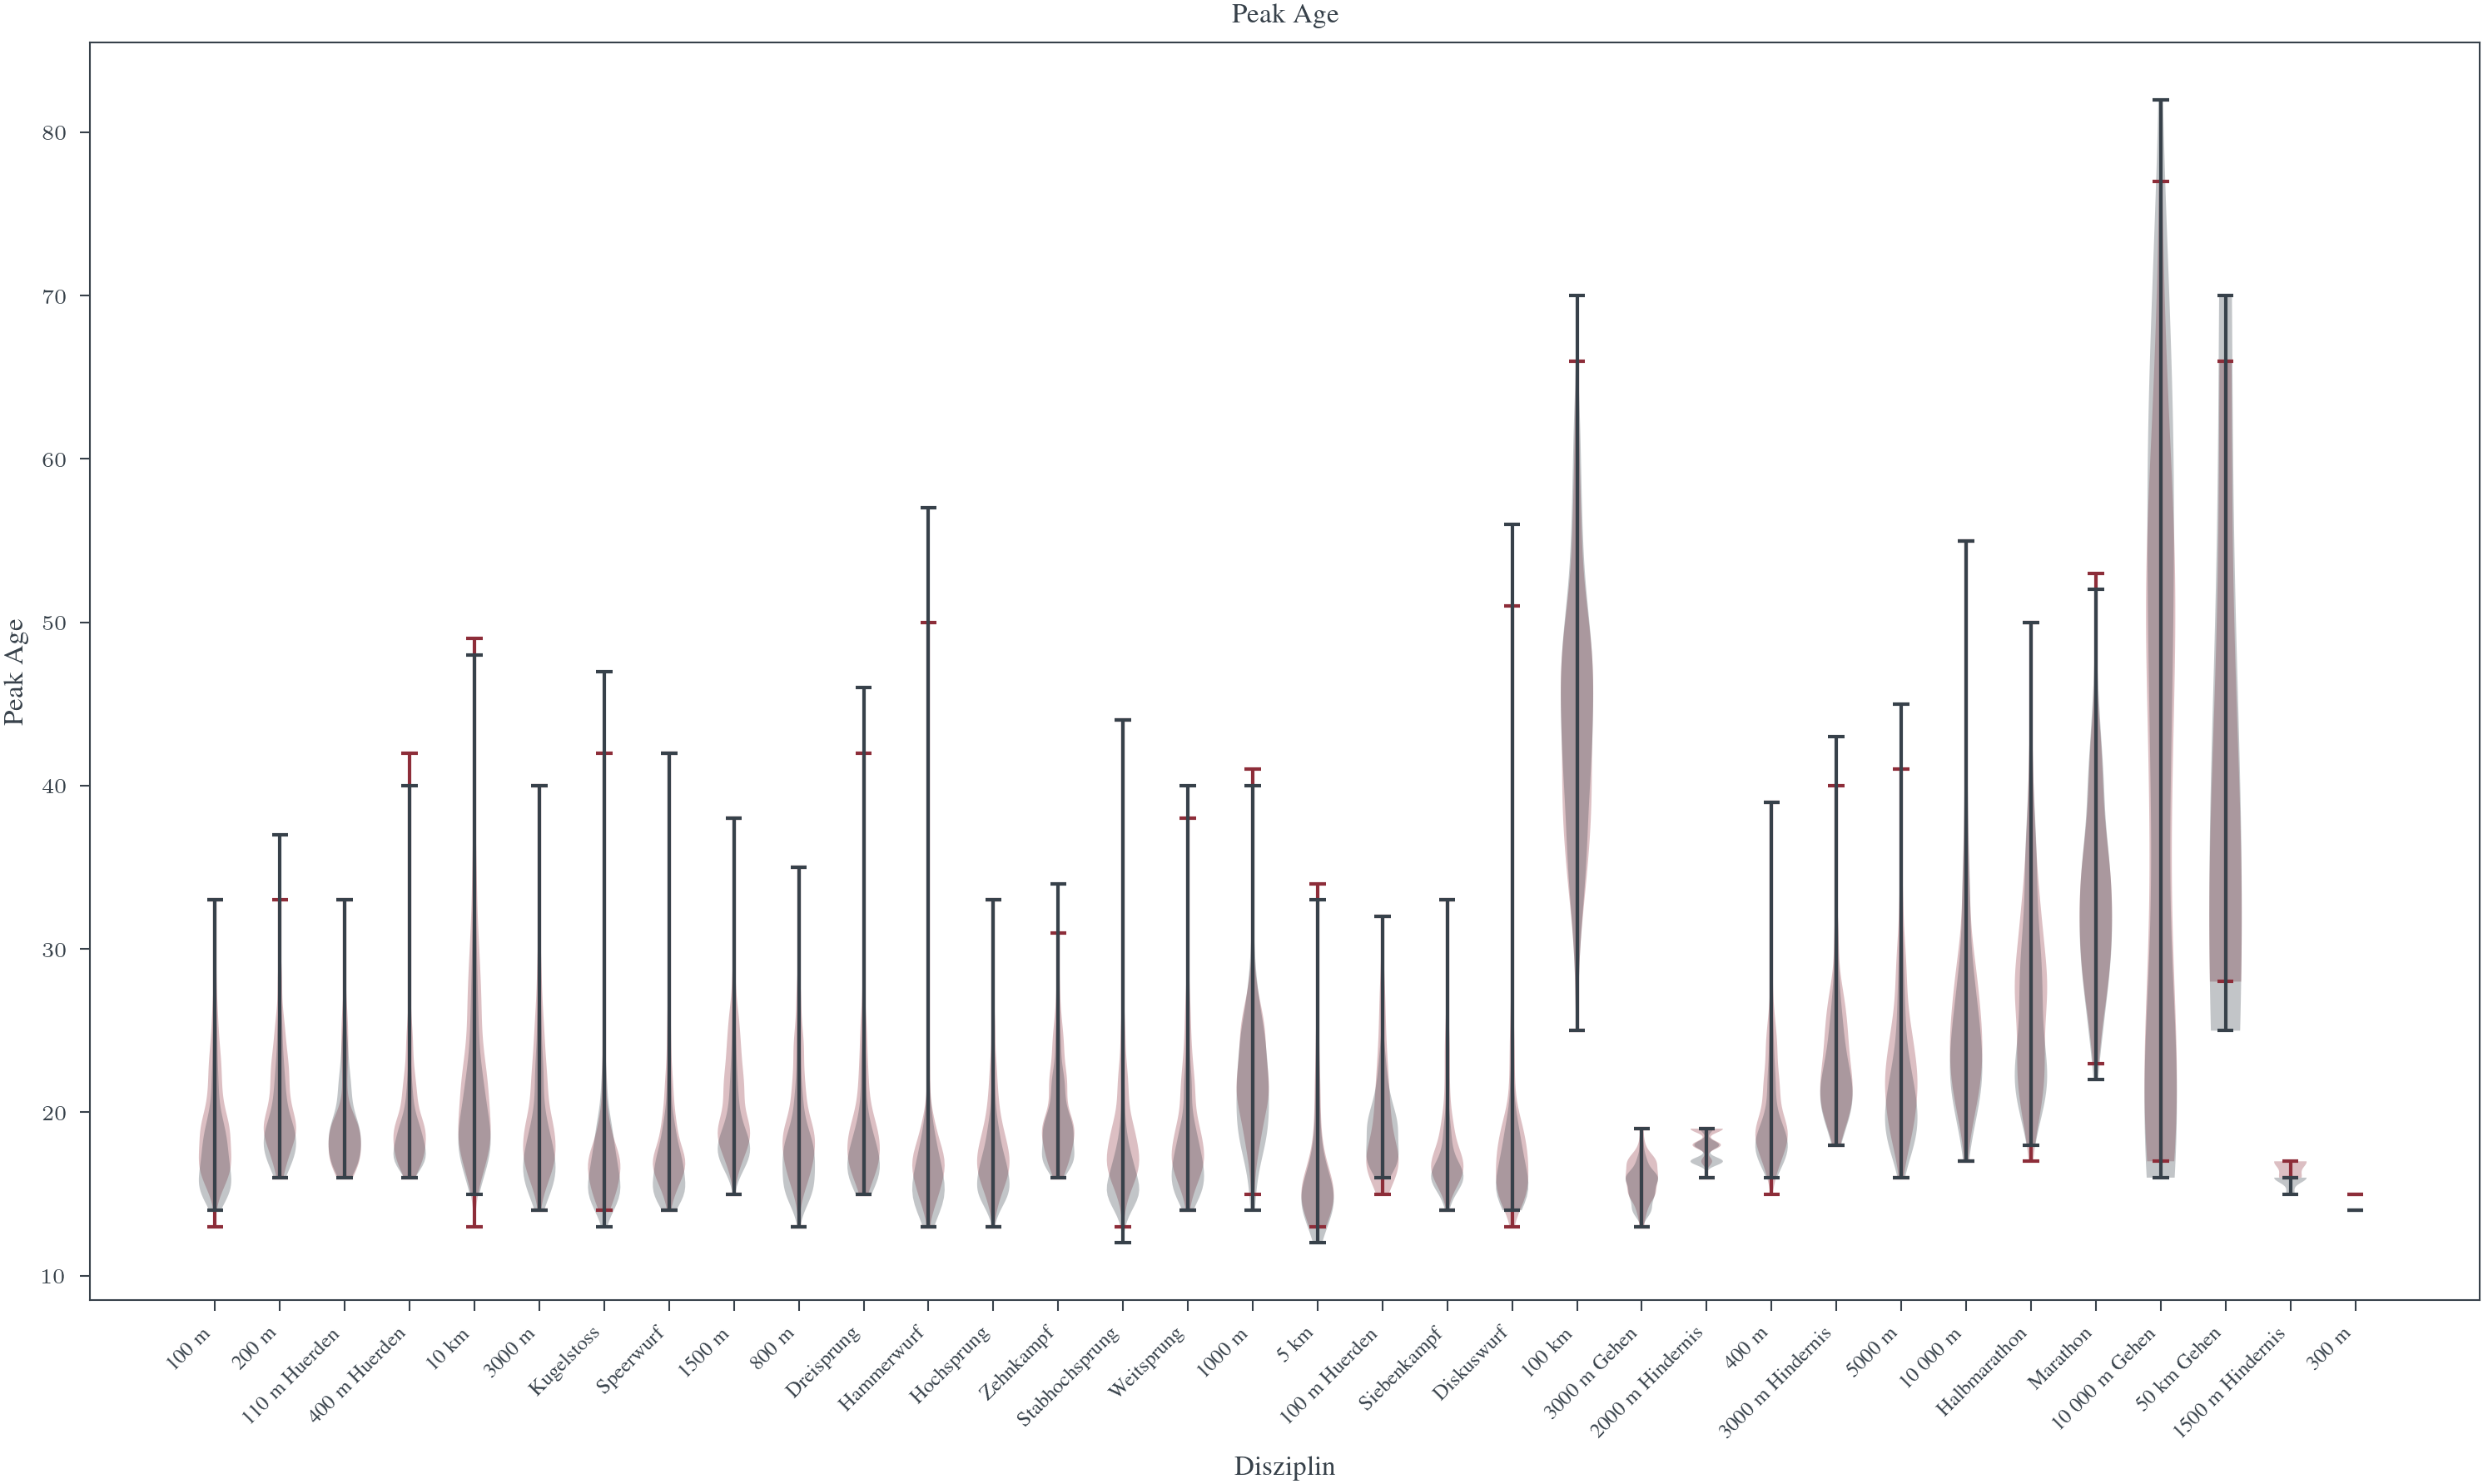

In [25]:
# 1. Daten vorbereiten: Wir gruppieren 'peak_age' nach 'disziplin'

categories = career_summary['disziplin'].unique()
peak_age_data = [career_summary[career_summary['disziplin'] == d]['peak_age'] for d in categories]
breakout_age_data = [career_summary[career_summary['disziplin'] == d]['breakout_age'] for d in categories]

# 2. Plot erstellen
fig, ax = plt.subplots(figsize=(10, 6))
ax.violinplot(peak_age_data)
ax.violinplot(breakout_age_data)

# 3. Achsen beschriften (Matplotlib setzt standardmäßig nur Zahlen 1, 2, 3...)
ax.set_xticks(range(1, len(categories) + 1))
fig.autofmt_xdate(rotation=45)
ax.set_xticklabels(categories)

ax.set_xlabel('Disziplin')
ax.set_ylabel('Peak Age')
ax.set_title('Peak Age')

plt.show()

[3.25, 2.0086104634371584]


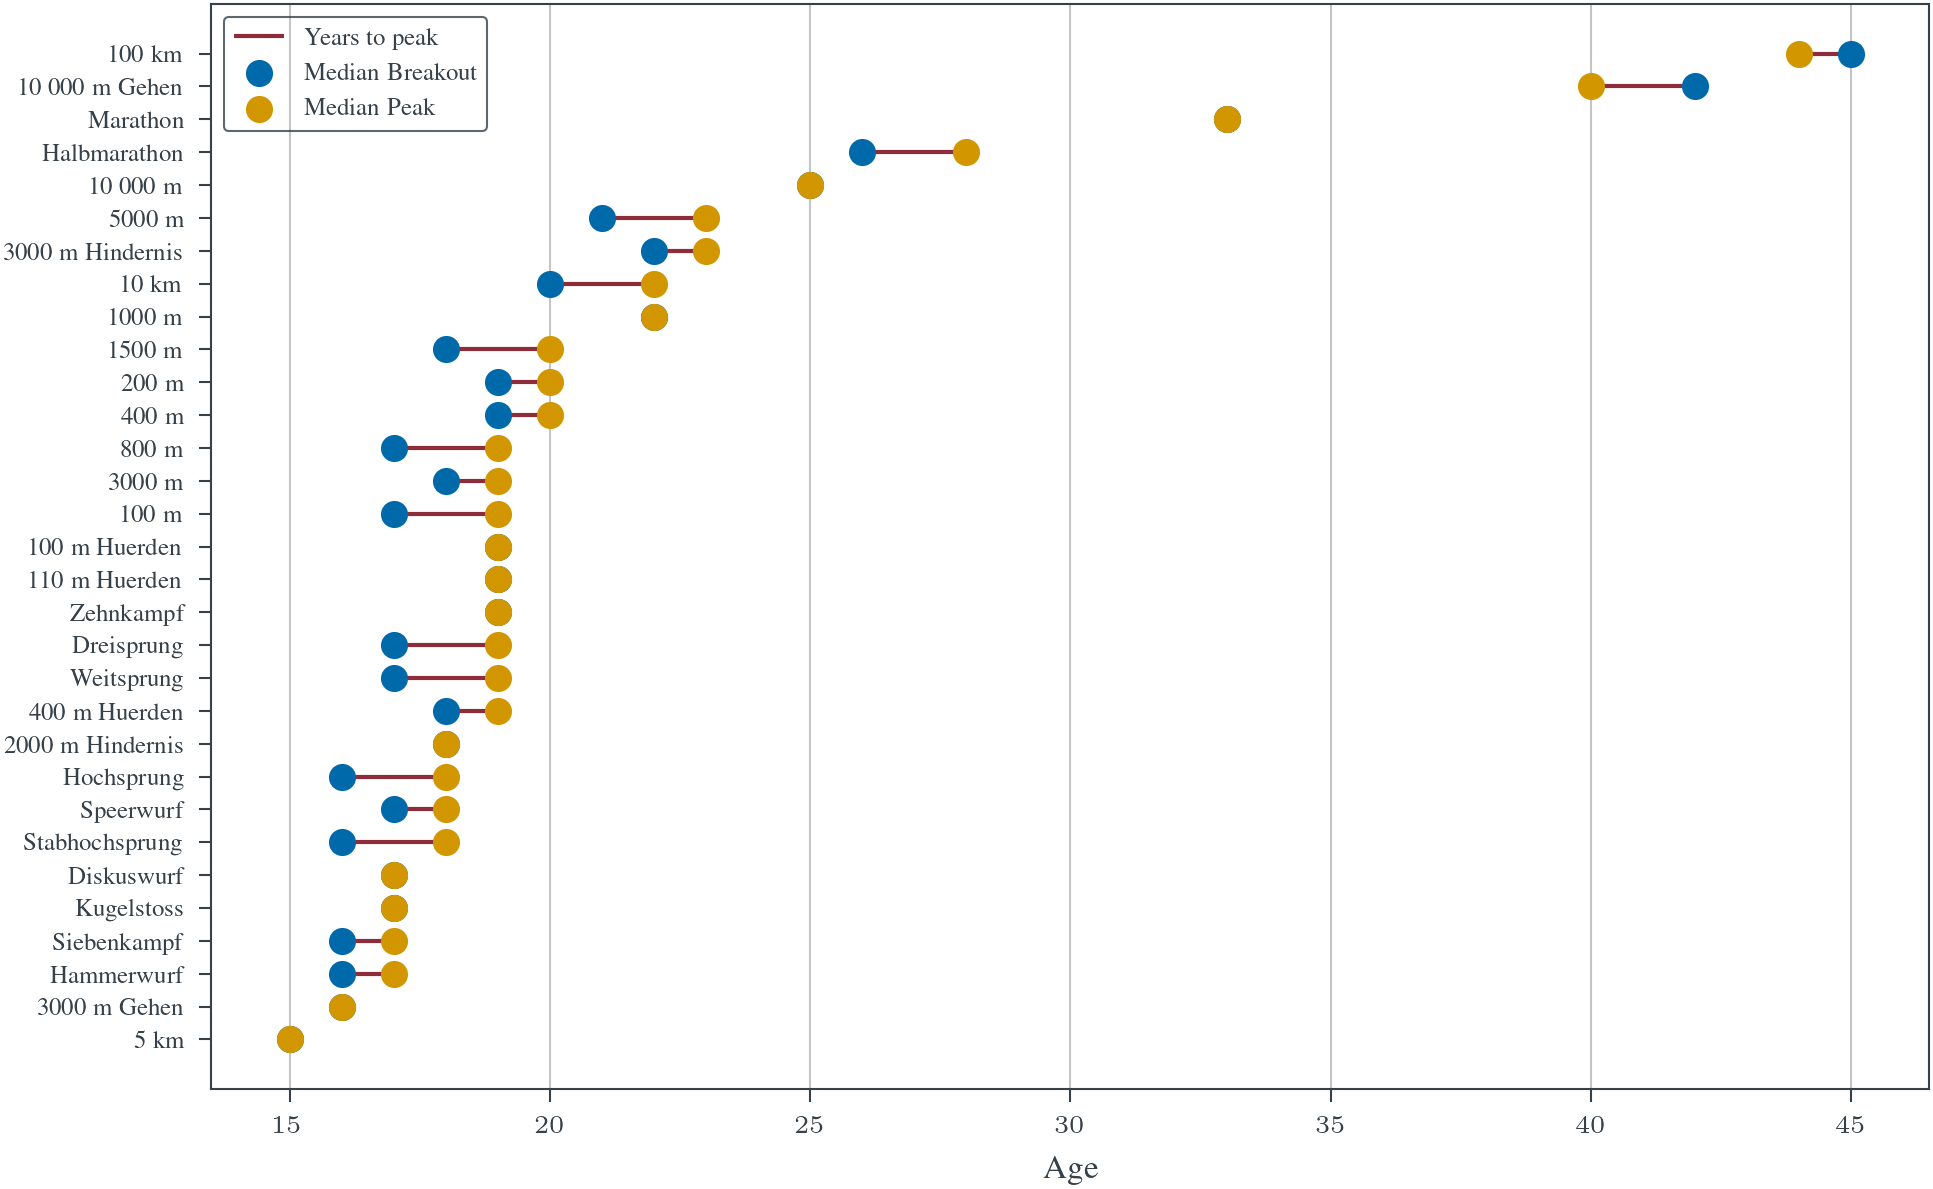

In [24]:
summary_filtered = discipline_summary[discipline_summary['n_athletes'] >= 10]
y = np.arange(len(summary_filtered))

print(plt.rcParams["figure.figsize"])

with plt.rc_context(plt.increase_figsze(2)):
    

    plt.hlines(
        y, 
        summary_filtered['median_breakout'],
        summary_filtered['median_peak'],
        label='Years to peak'
    )

    plt.scatter(
        summary_filtered['median_breakout'],
        y,
        label='Median Breakout',
        zorder=3,
        color=rgb.tue_blue
    )

    plt.scatter(
        summary_filtered['median_peak'],
        y,
        label='Median Peak',
        zorder=3,
        color=rgb.tue_orange
    )

    plt.yticks(y, summary_filtered.index)
    plt.xlabel('Age')
    plt.legend()
    plt.xticks()
    plt.grid(axis='x', alpha=0.3)

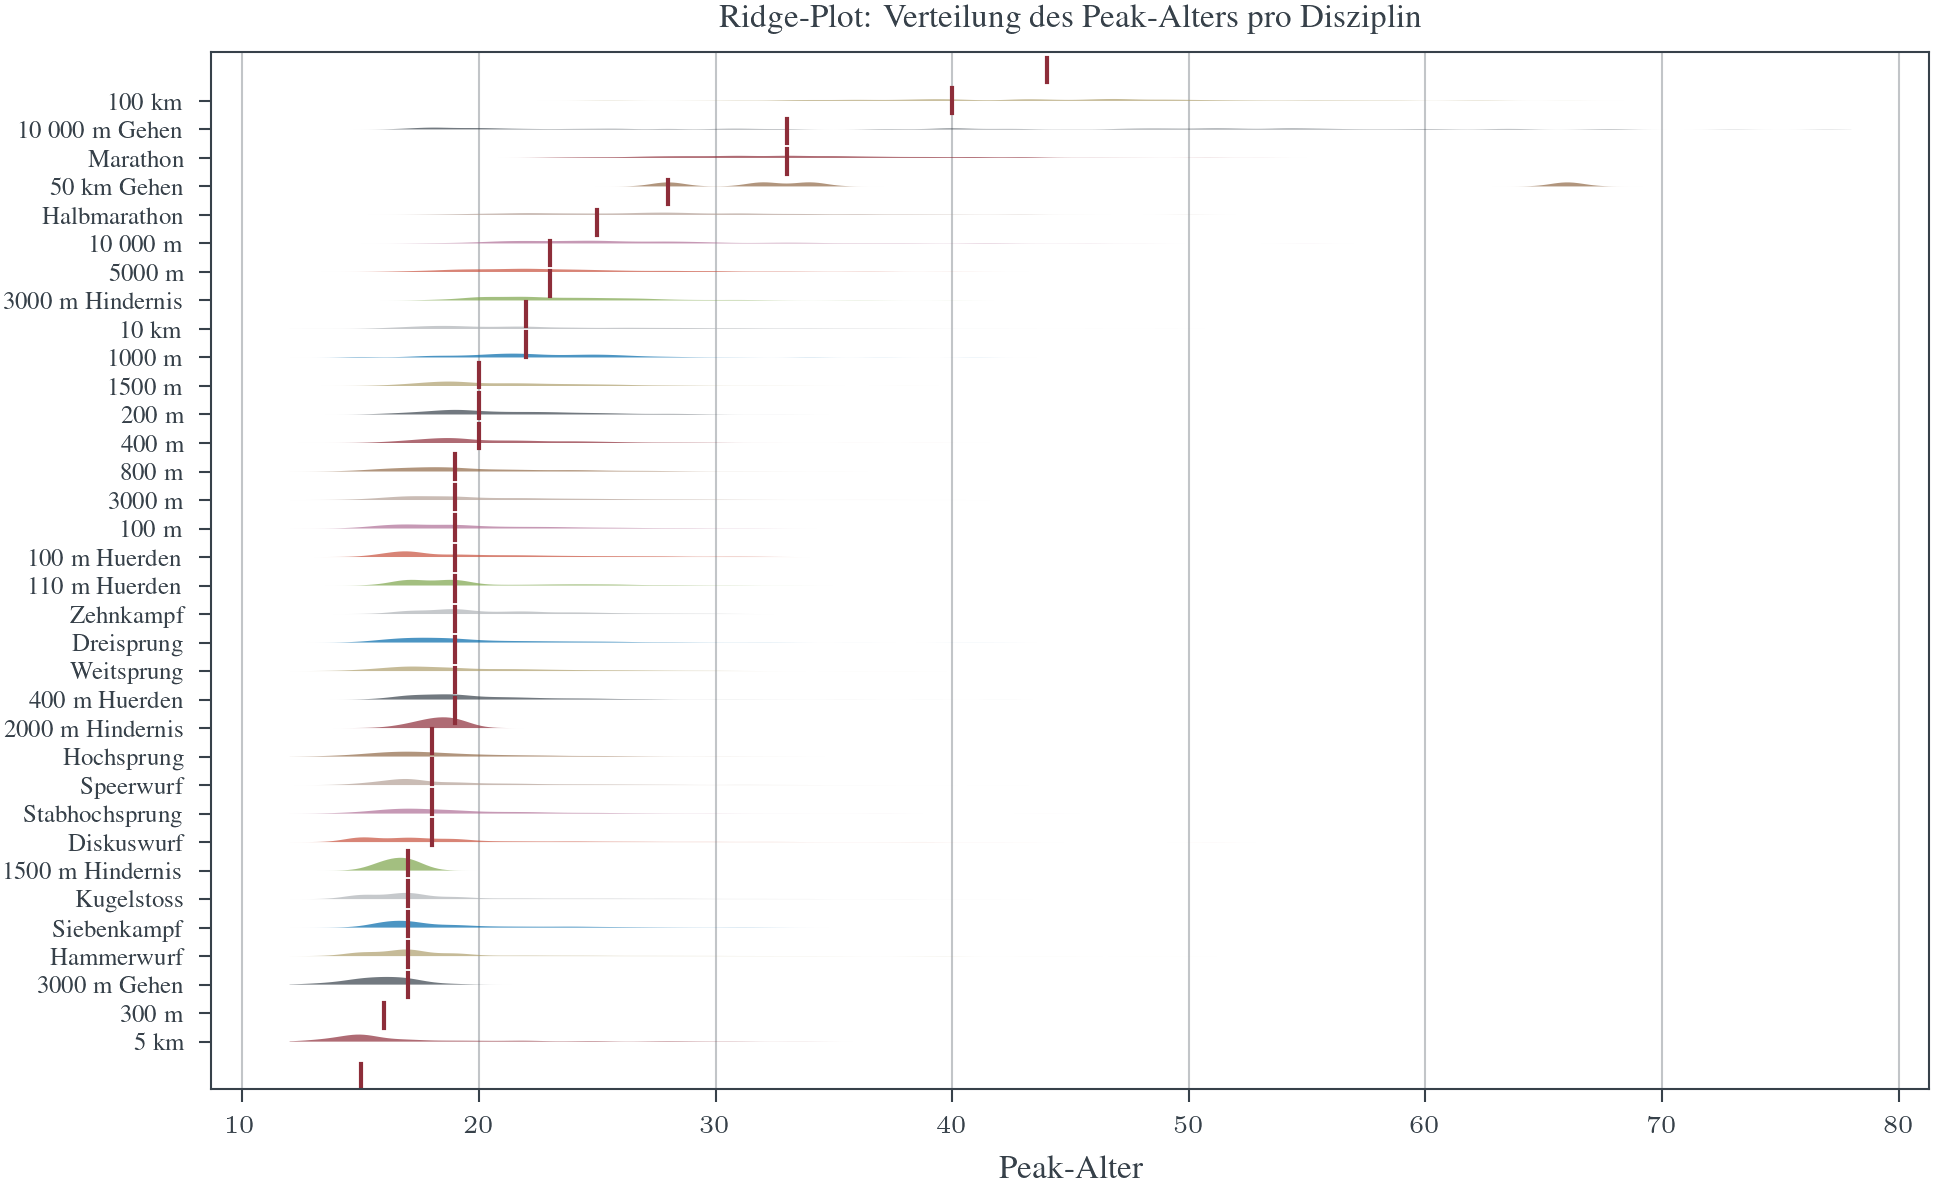

In [22]:
disciplines = (
    career_summary
    .groupby('disziplin')['peak_age']
    .median()
    .sort_values()
    .index
)

def kde_smooth(x, grid, bandwidth=0.6):
    x = np.asarray(x)
    return np.sum(
        np.exp(-0.5 * ((grid[:, None] - x[None, :]) / bandwidth) ** 2),
        axis=1
    ) / (len(x) * bandwidth * np.sqrt(2 * np.pi))


with plt.rc_context(plt.increase_figsze(2)):
    fig, ax = plt.subplots()

    x_grid = np.linspace(
        career_summary['peak_age'].min() - 1,
        career_summary['peak_age'].max() + 1,
        400
    )

    offset = 1.0  # vertikaler Abstand zwischen Disziplinen

    for i, d in enumerate(disciplines):
        data = career_summary.loc[
            career_summary['disziplin'] == d,
            'peak_age'
        ]

        if len(data) < 3:
            continue  # zu wenig Daten für KDE

        density = kde_smooth(data, x_grid, bandwidth=0.7)

        ax.fill_between(
            x_grid,
            i * offset,
            density + i * offset,
            alpha=0.7
        )

        # Median-Linie
        ax.axvline(
            np.median(data),
            ymin=(i * offset) / (len(disciplines) * offset),
            ymax=((i + 0.8) * offset) / (len(disciplines) * offset),
            linewidth=1
        )


    ax.set_yticks(
        np.arange(len(disciplines)) * offset
    )
    ax.set_yticklabels(disciplines)

    ax.set_xlabel('Peak-Alter')
    ax.set_title('Ridge-Plot: Verteilung des Peak-Alters pro Disziplin')

    ax.grid(axis='x', alpha=0.3)